# Lab 3

## This notebook should be used in conjunction with the Canvas Quiz: Computational Physics Lab 3. Use the notebook to run scripts and make notes. Submit your final answers on Canvas.

# Part I: Solving the Simple Pendulum with Velocity-Verlet

These questions involve modifying simplependulum.ipynb from the third lecture, which uses RK4,  to instead use the Velocity-Verlet method (from the second lecture), and interpreting the results. 

In lectures, we considered the simple pendulum, which has the non-dimensional equation of motion $\frac{d^2\theta}{dt^2}=-4\pi^2\sin\theta,$ where $\theta =\theta (t)$ is the angle to the vertical at time $t.$ Note that the scaling of length and time is such that the period of small amplitude oscillations is $T_0=1.$

The code expproblem_and_simplependulum.ipynb from Lecture 3 integrates the pendulum equation of motion using fourth-order Runge-Kutta (RK4). Review the code and make sure you understand how it works.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def rhs_pend(x):

    #----------------------------------------------------------------------------
    # rhs_pend: Evaluate the right hand side of the coupled (non-
    #    dimensional) ODEs describing the nonlinear pendulum
    #
    #---INPUT:
    # x - the current value of the dependent variable. For the pendulum
    #    ODEs x = [theta omega] where theta is the angle and omega is the
    #    angular velocity.
    #    
    #---OUTPUT:
    # rhs - a row vector representing the value of the right hand side
    #    of the ODEs. Specifically, rhs=[omega -4*pi^2*sin(theta)].
    #-------------------------------------------------------------------------------
 
    
    rhs = np.zeros(2)
    
    theta = x[0];
    omega = x[1];
    rhs[0] = omega;
    rhs[1] = -4*np.pi**2*np.sin(theta)
    
    return rhs

## <span style="color:red">Q1</span>
### Modify the simplependulum.ipynb code so that it also plots $\theta$ versus $t.$ Run the code and produce $\theta$ versus $t$ plots for numerical integrations from $t=0$ to $t=7$ with time steps $\tau=0.01,\,0.1,\,0.2,\,1,$ and with initial angles $\theta_1=10,\,45,\,90,\,170\,{\rm deg}.$

For which time steps, and which initial angles, is the numerical solution *reasonably accurate*?

In [3]:
%matplotlib inline

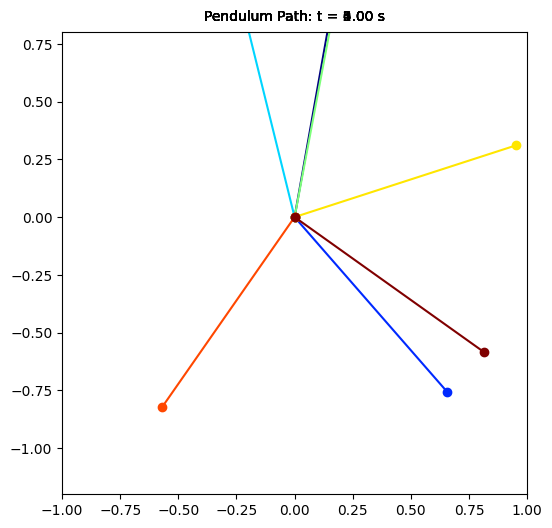

In [4]:
#-------------------------------------------------------------------------------
# Time grid parameters:
tau_vec = np.array([0.01, 0.1, 0.2, 1])
theta1_vec = np.array([10, 45, 90, 170])

for tau, theta1 in np.array([tau_vec, theta1_vec]).T:
    T = 7  # Total integration time
    numSteps = int(np.ceil(T/tau))  # Number of time steps

    #-------------------------------------------------------------------------------
    # Initial conditions
    theta = theta1*np.pi/180
    x = np.array([theta, 0])

    #-------------------------------------------------------------------------------
    # Preallocate:
    time = np.arange(numSteps+1)*tau

    # Arrays to store pendulum positions
    xPendArray = np.zeros((numSteps+1, 2))
    yPendArray = np.zeros((numSteps+1, 2))

    # Initial position
    xPendArray[0] = [0, np.sin(x[0])]
    yPendArray[0] = [0, -np.cos(x[0])]


    #-------------------------------------------------------------------------------
    # Fourth-order Runge-Kutta integration
    for n in range(numSteps):
        
        # One step of RK4
        f1 = rhs_pend(x)
        f2 = rhs_pend(x + 0.5*tau*f1)
        f3 = rhs_pend(x + 0.5*tau*f2)
        f4 = rhs_pend(x + tau*f3)
        x = x + tau*(f1 + 2*f2 + 2*f3 + f4)/6
        
        # Update the pendulum position:
        # Co-ordinates of the pendulum bar
        xPendArray[n+1] = [0, np.sin(x[0])]
        yPendArray[n+1] = [0, -np.cos(x[0])]


#-------------------------------------------------------------------------------
# Plot the results as an animation

# %matplotlib widget 
# This enables interactive mode; uncomment and run the following line to go back to static:
%matplotlib inline

# Set up figure
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim([-1, 1])
ax.set_ylim([-1.2, 0.8])

# Plot pendulum paths with rainbow colors
artists = []
colors = plt.cm.jet(np.linspace(0, 1, numSteps))

for i in range(numSteps):
            
    plot,  = ax.plot(xPendArray[i], yPendArray[i], 'o-', color=colors[i]) # Plot pendulum positions
    
    title = ax.text(0, 0.85, f'Pendulum Path: t = {time[i]:.2f} s', ha='center')
    
    artists.append([plot, title])
    
ani = animation.ArtistAnimation(fig=fig, artists=artists, interval=80, repeat=False)
plt.show()
# Change interval value to speed up or slow down animation

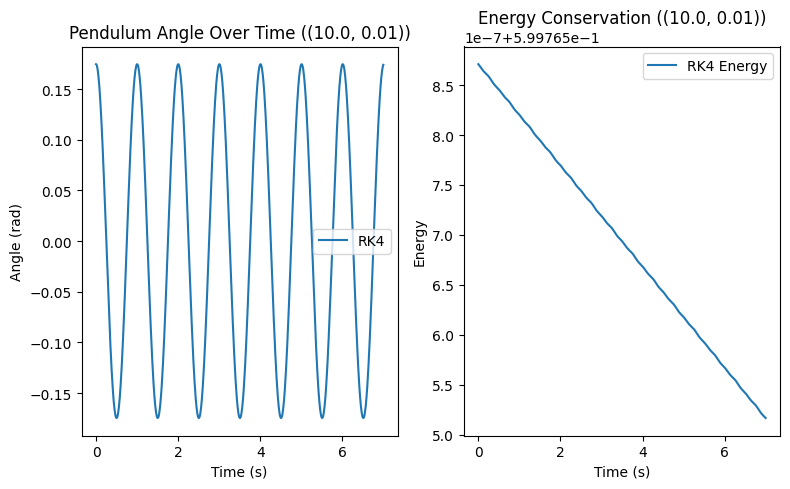

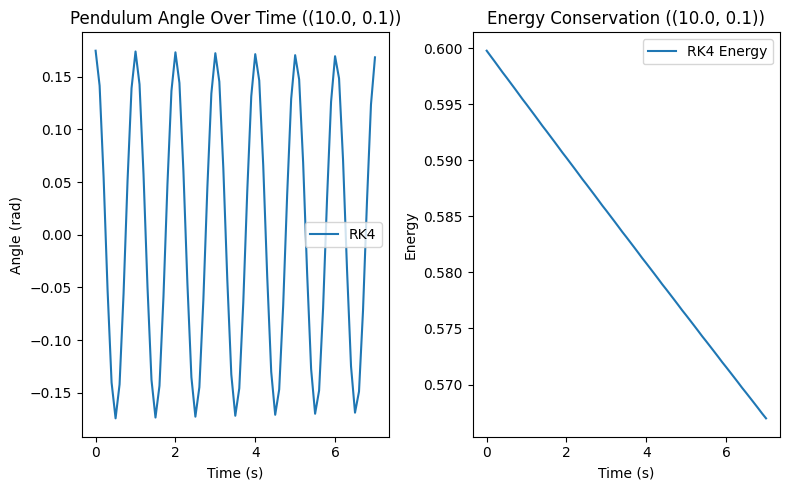

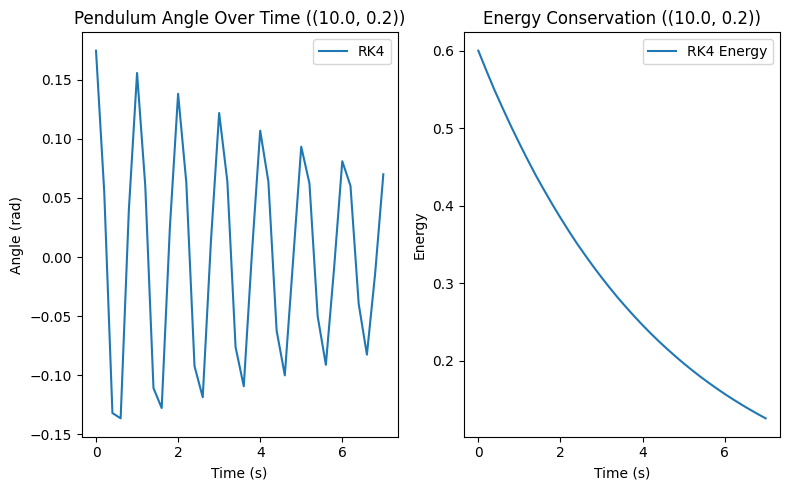

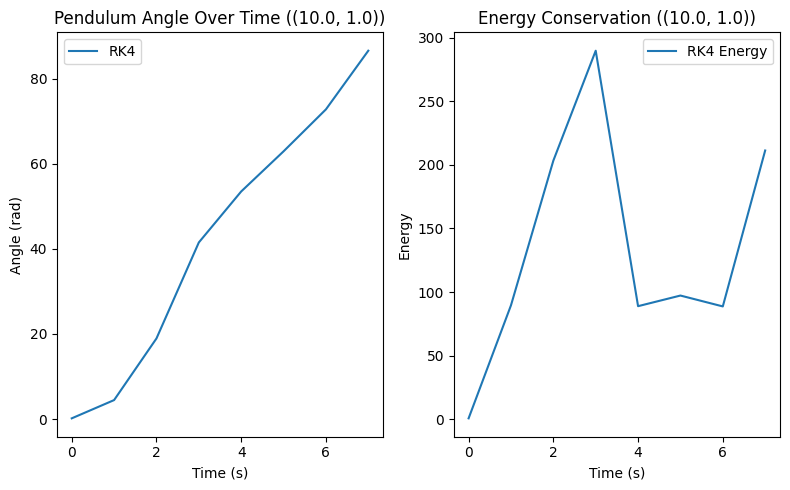

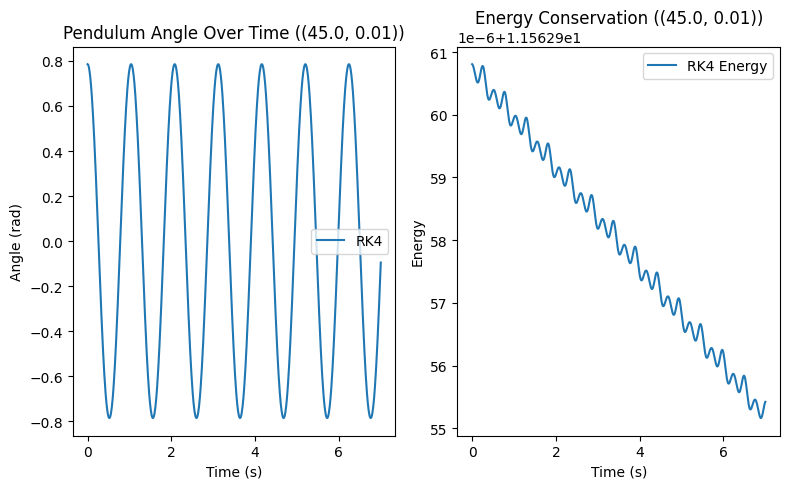

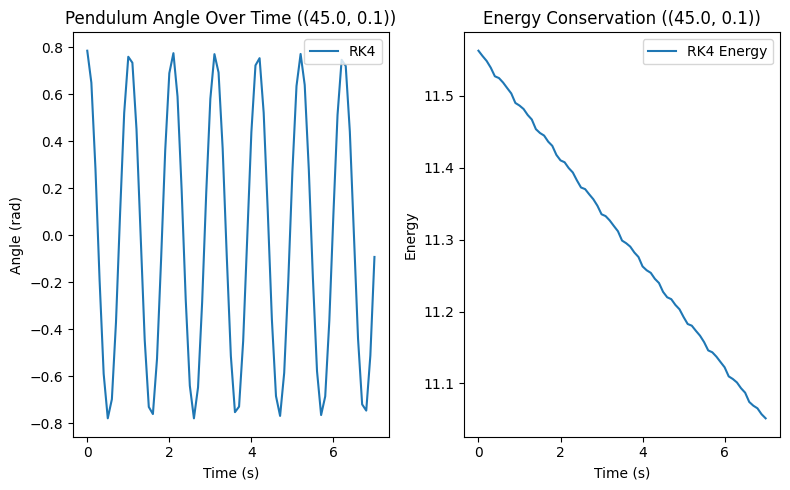

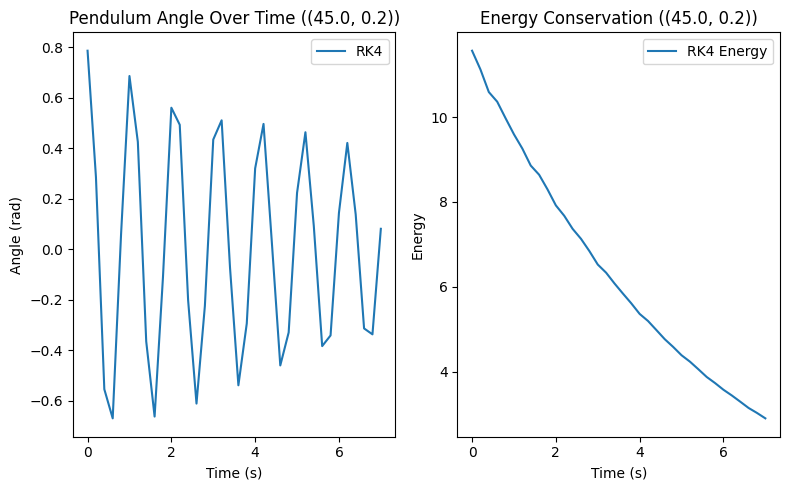

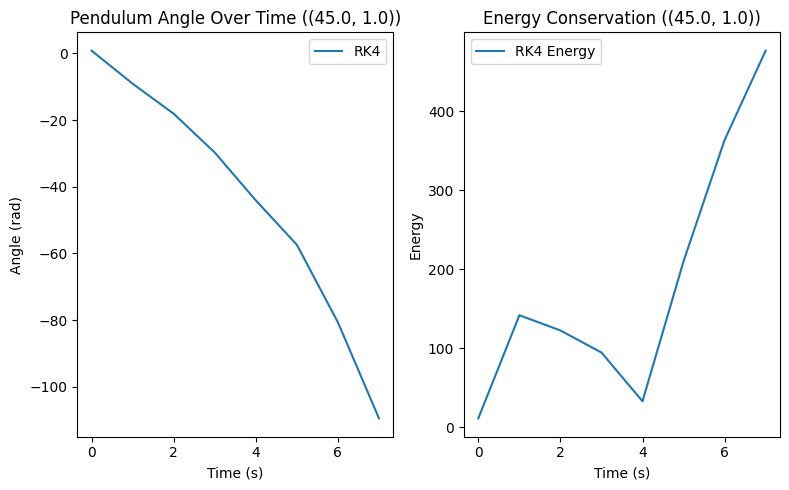

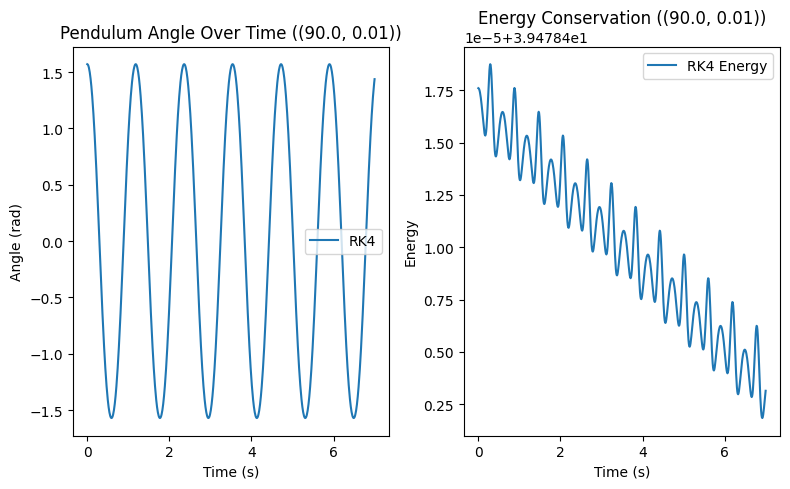

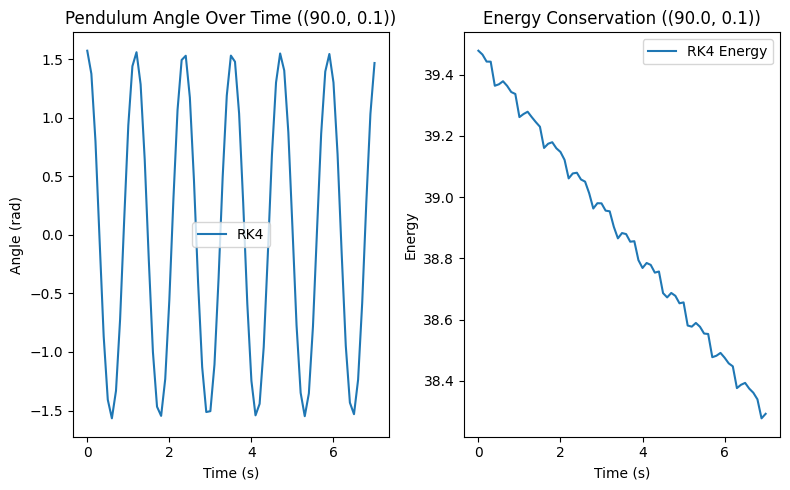

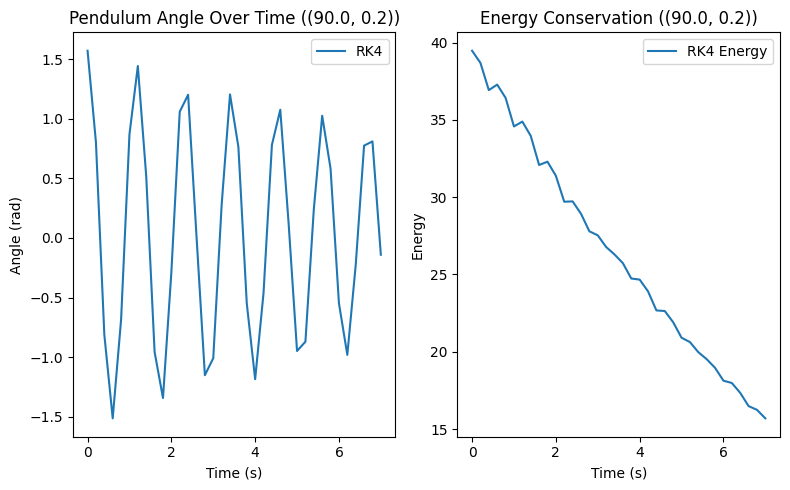

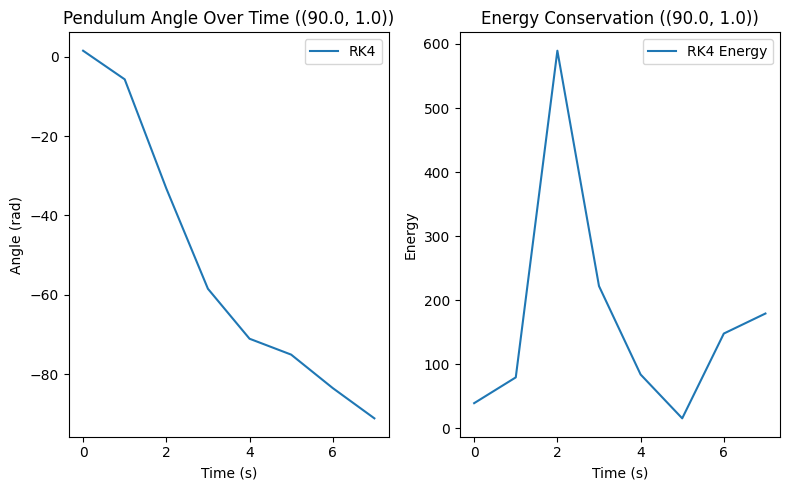

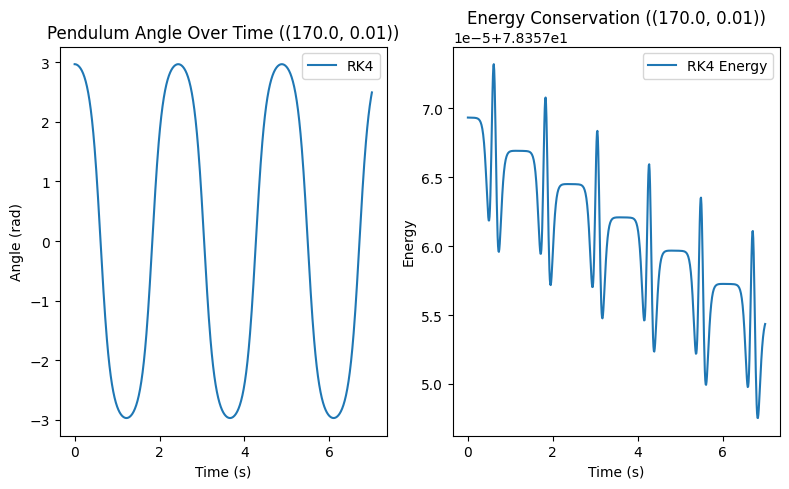

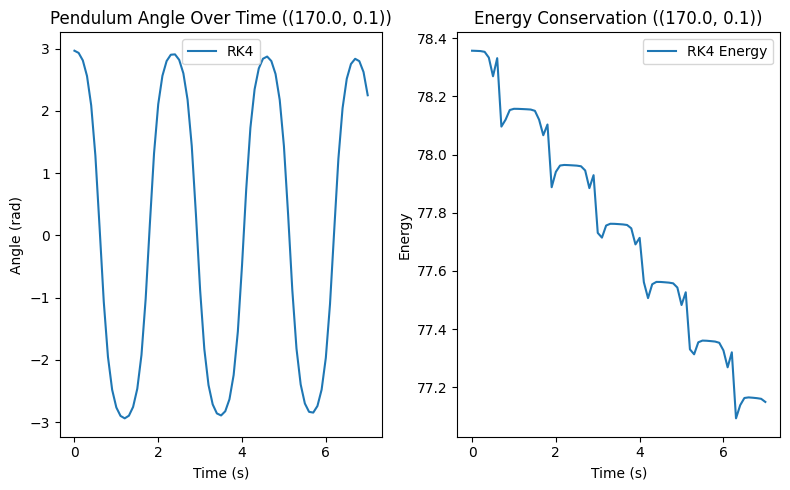

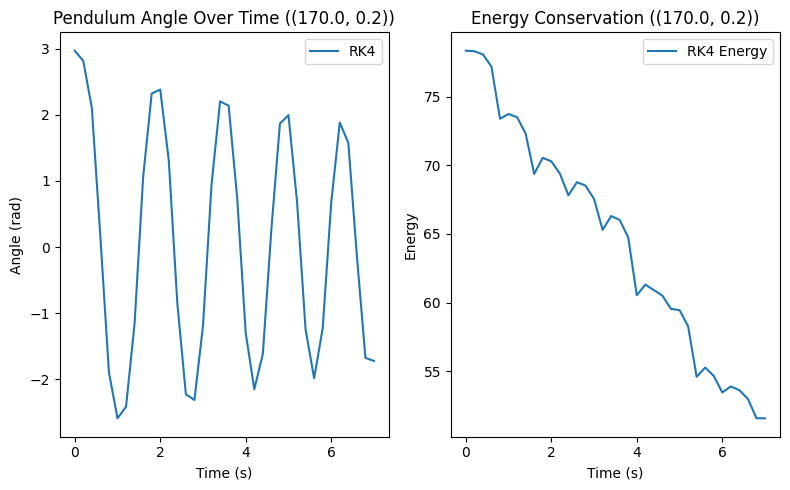

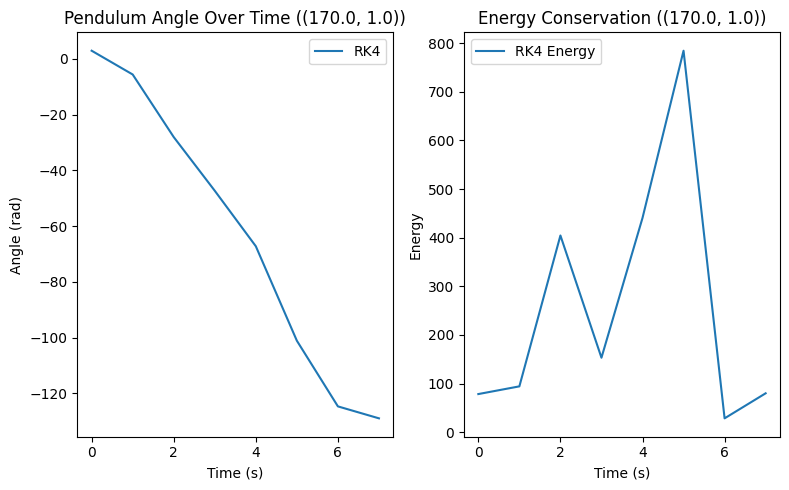

In [5]:
tau_vec = np.array([0.01, 0.1, 0.2, 1])
theta0_vec = np.array([10, 45, 90, 170])

for i, theta0_deg in enumerate(theta0_vec):
    for j, tau in enumerate(tau_vec):

        # Define parameters
        T = 7       # Total integration time
        numSteps = int(np.ceil(T / tau))
        time = np.arange(numSteps + 1) * tau

        # Initial conditions
        theta0 = np.radians(theta0_deg)
        x0 = np.array([theta0, 0.0])  # [theta, omega]

        # Define RHS of the pendulum ODEs
        def rhs_pend(x):
            theta, omega = x
            dtheta_dt = omega
            domega_dt = -4 * np.pi**2 * np.sin(theta)
            return np.array([dtheta_dt, domega_dt])

        # Function to compute energy
        def pendulum_energy(x):
            theta, omega = x
            kinetic = 0.5 * omega**2
            potential = 4 * np.pi**2 * (1 - np.cos(theta))
            return kinetic + potential

        # Runge-Kutta 4th Order
        x_rk = x0.copy()
        rk_data = [x_rk.copy()]
        rk_energy = [pendulum_energy(x_rk)]

        for _ in range(numSteps):
            f1 = rhs_pend(x_rk)
            f2 = rhs_pend(x_rk + 0.5 * tau * f1)
            f3 = rhs_pend(x_rk + 0.5 * tau * f2)
            f4 = rhs_pend(x_rk + tau * f3)
            x_rk = x_rk + (tau / 6) * (f1 + 2 * f2 + 2 * f3 + f4)
            rk_data.append(x_rk.copy())
            rk_energy.append(pendulum_energy(x_rk))

        # Euler Method
        x_euler = x0.copy()
        euler_data = [x_euler.copy()]
        euler_energy = [pendulum_energy(x_euler)]

        for _ in range(numSteps):
            f = rhs_pend(x_euler)
            x_euler = x_euler + tau * f
            euler_data.append(x_euler.copy())
            euler_energy.append(pendulum_energy(x_euler))

        # Convert to numpy arrays
        rk_data = np.array(rk_data)
        euler_data = np.array(euler_data)
        rk_energy = np.array(rk_energy)
        euler_energy = np.array(euler_energy)

        # Plot theta over time
        plt.figure(figsize=(8, 5))
        plt.subplot(1, 2, 1)
        plt.plot(time, rk_data[:, 0], label="RK4")
        # plt.plot(time, euler_data[:, 0], label="Euler", linestyle='dashed')
        plt.xlabel("Time (s)")
        plt.ylabel("Angle (rad)")
        plt.title(f"Pendulum Angle Over Time ({float(theta0_deg), float(tau)})")
        plt.legend()

        # Plot energy over time
        plt.subplot(1, 2, 2)
        plt.plot(time, rk_energy, label="RK4 Energy")
        # plt.plot(time, euler_energy, label="Euler Energy", linestyle='dashed')
        plt.xlabel("Time (s)")
        plt.ylabel("Energy")
        plt.title(f"Energy Conservation ({float(theta0_deg), float(tau)})")
        plt.legend()
        plt.tight_layout()
        plt.show()


|      | 10 | 45 | 90 | 170 |
|------|----|----|----|-----|
| 0.01 |  A  |  A  |  A  |   A  |
| 0.1  | A   |  A  |  A  |   A  |
| 0.2  |  I  |  I  |  I  |   I  |
| 1    |  I  |  I  |  I |   I  |

*Your notes:*

## <span style="color:red">Q2</span>
### There is some subjectivity in how you deﬁne whether a numerical solution is “reasonably accurate”.

Which of the following could be a valid way of determining whether a numerical solution of pendulum motion is accurate? 

*Your notes:*

## <span style="color:red">Q3</span>
### Velocity-Verlet Method for Pendulum Dynamics

Velocity-Verlet is the variant of the Verlet method introduced in Lecture 2. For the general dynamics problem Velocity-Verlet may be written:

$${\bf r}_{n+1}={\bf r}_n+\tau {\bf v}_{n}+\frac{1}{2}\tau^2{\bf a}_n$$

and

$$ {\bf v}_{n+1}= {\bf v}_n+\tfrac{1}{2}\tau\left({\bf a}_n+{\bf a}_{n+1}\right).$$

Using your RK4 method as a starting point, create new Python code which solves the pendulum problem using Velocity-Verlet instead of fourth-order Runge-Kutta.

*Hints*: Note that, for the pendulum ODEs the correspondence with the dynamics equations for 1-D motion with position $x$ and velocity $v$ is:

$$ x\quad \Leftrightarrow \quad \theta, $$
$$v=\frac{dx}{dt}\quad \Leftrightarrow \quad \omega=\frac{d\theta}{dt}, $$
$$a=\frac{dv}{dt}\quad \Leftrightarrow \quad \alpha = \frac{d\omega}{dt}=-4\pi^2\sin\theta.$$

Hence the Velocity-Verlet updates for the pendulum are:

$$ \theta_{n+1}=\theta_n+\tau \omega_{n}+\tfrac{1}{2}\tau^2\alpha_n$$

and

$$\omega_{n+1}= \omega_n+\frac{1}{2}\tau\left(\alpha_n+\alpha_{n+1}\right),$$

where $\alpha_n=-4\pi^2\sin\theta_n.$

When you have your Velocity-Verlet code for the pendulum problem working, repeat the calculations from 1, placing an A (accurate) or I (inaccurate) in each place in the table below:

 $\theta_1=10$ deg $\theta_1=45$ deg $\theta_1=90$ deg $\theta_1=170$ deg $\tau=0.01$        
$\tau=0.1$
       $\tau=0.2$         $\tau=1$        

Compare your table to the one you generated above for RK4. You will notice that there is a one entry that is accurate for VV but inaccurate for RK4:
Compared to RK4 (which gave an inaccurate solution), the VV method is more accurate for $\tau = 0.2$.

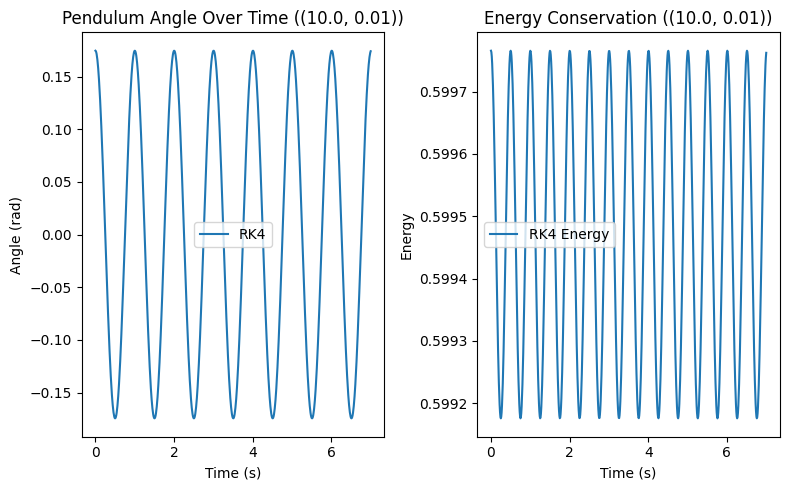

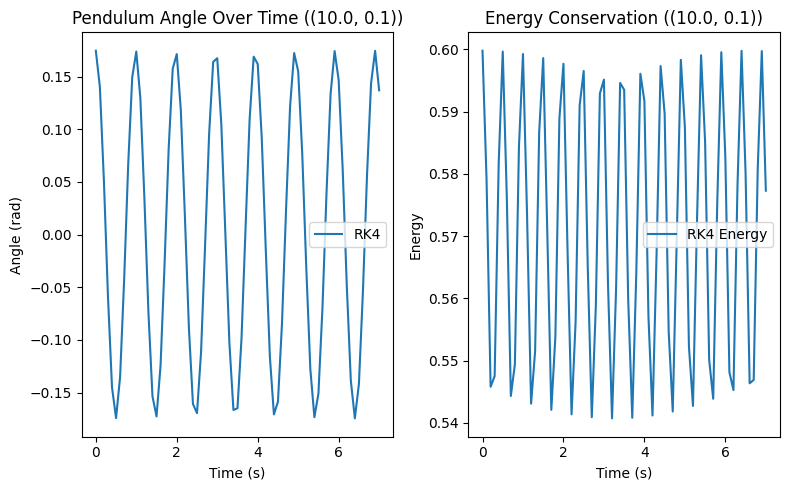

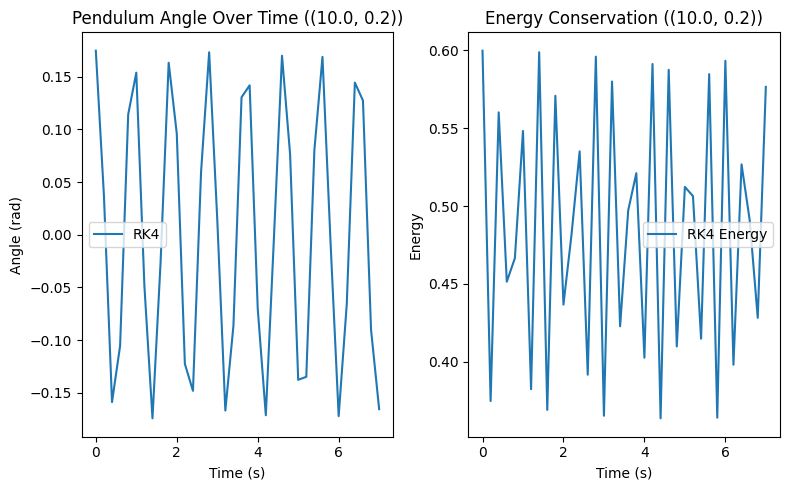

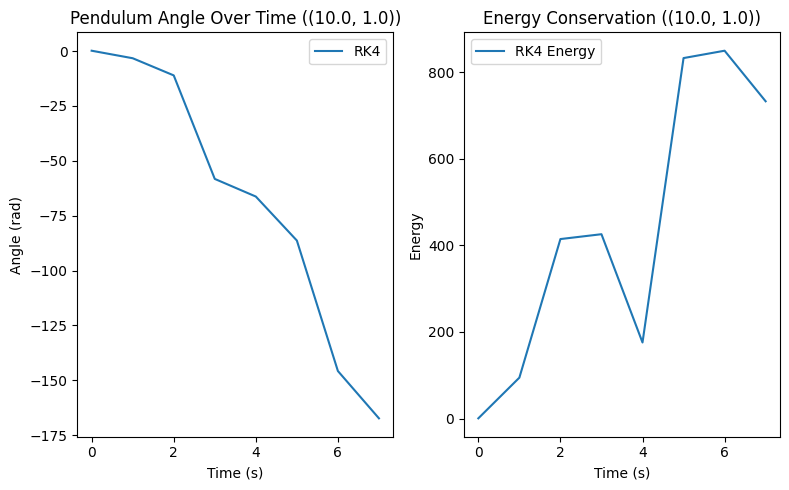

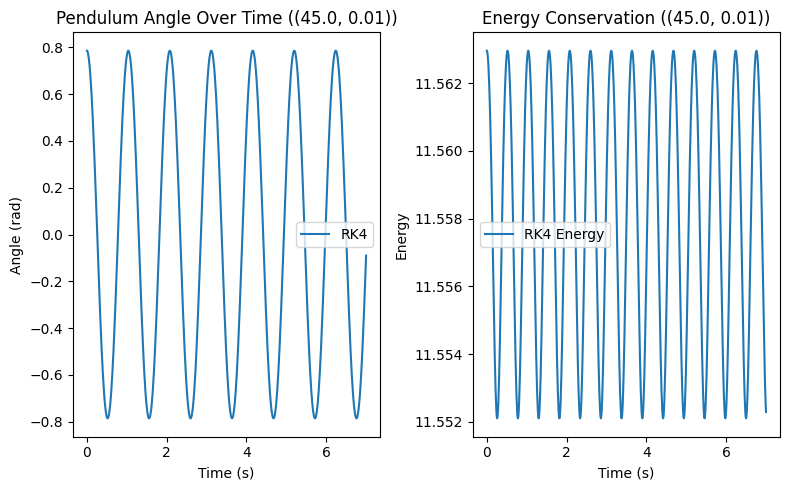

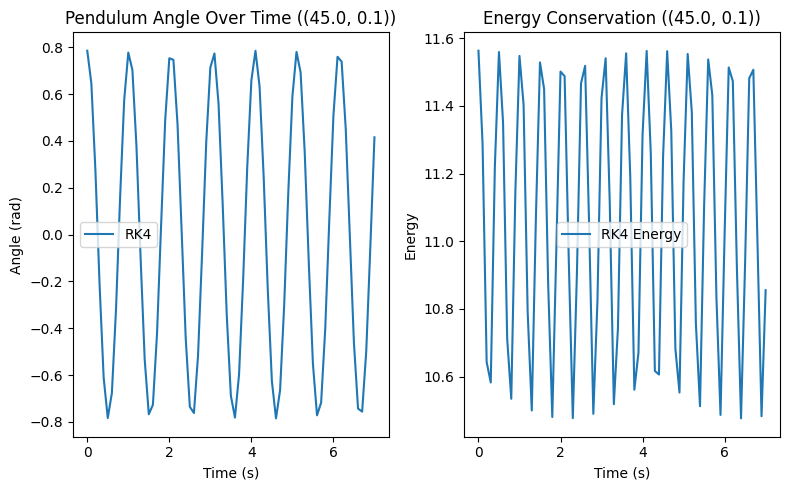

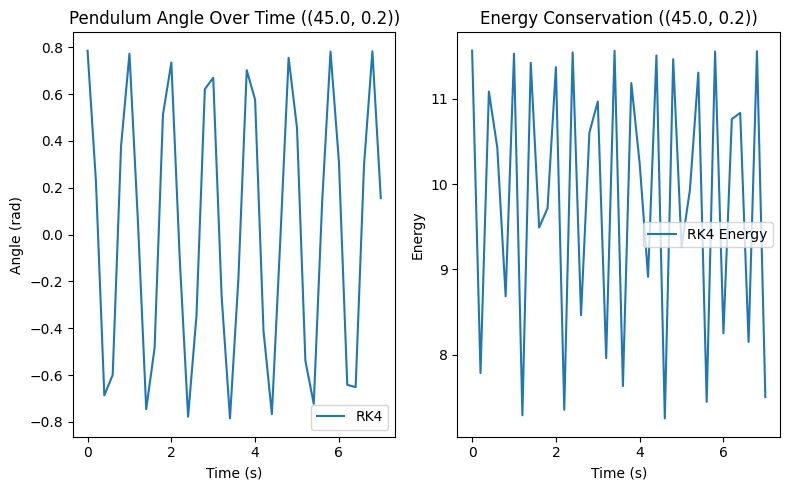

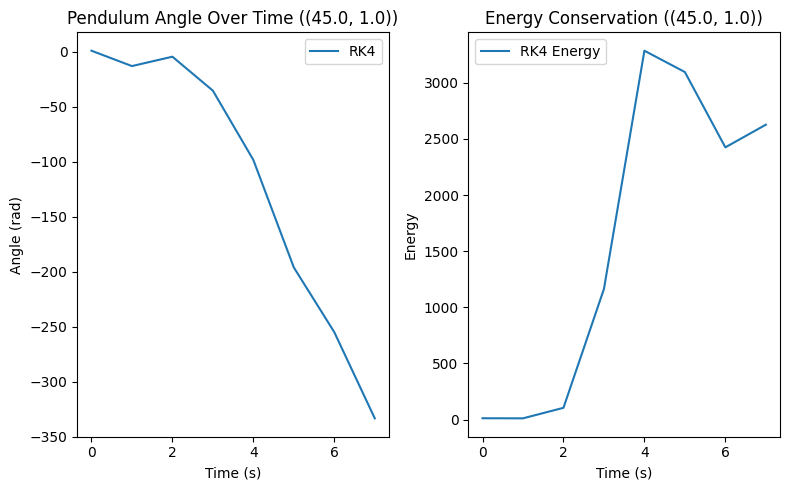

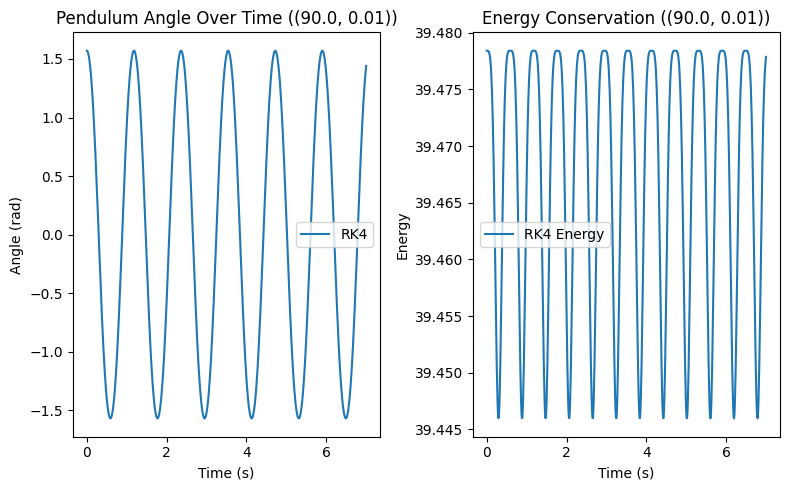

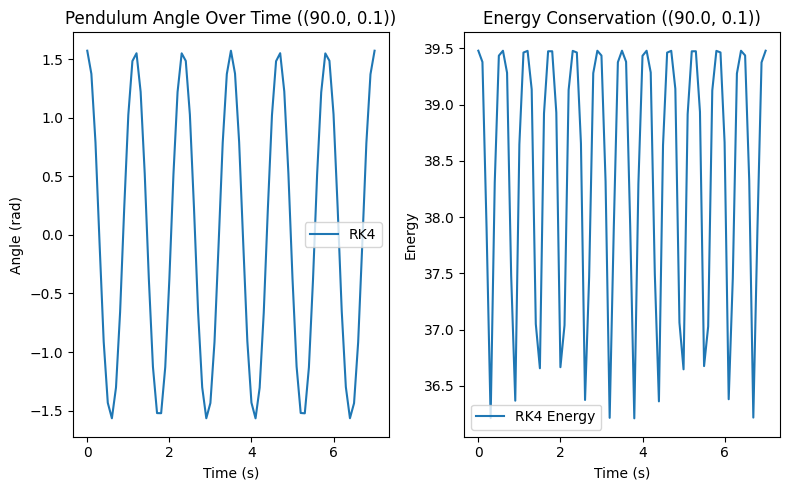

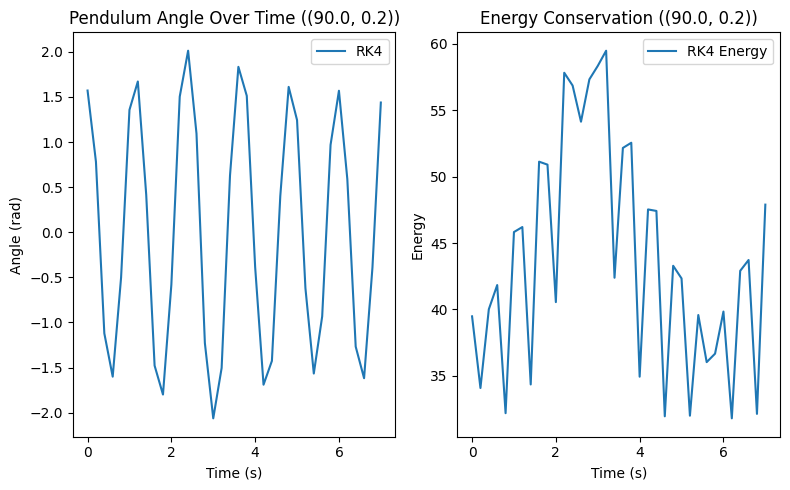

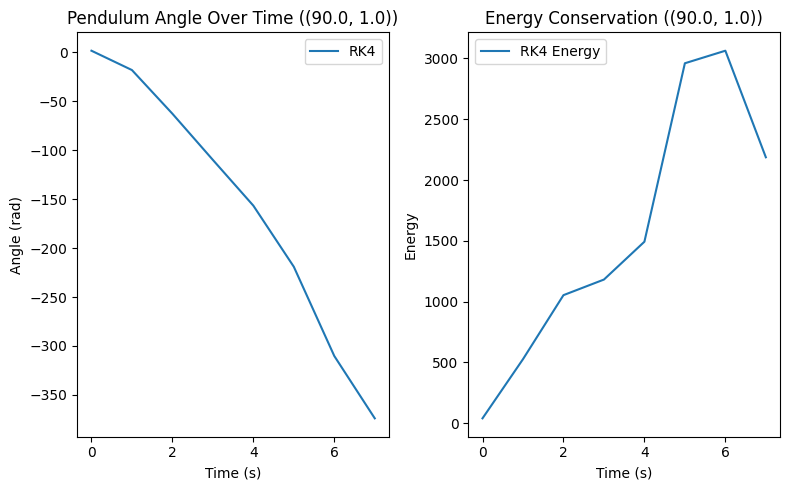

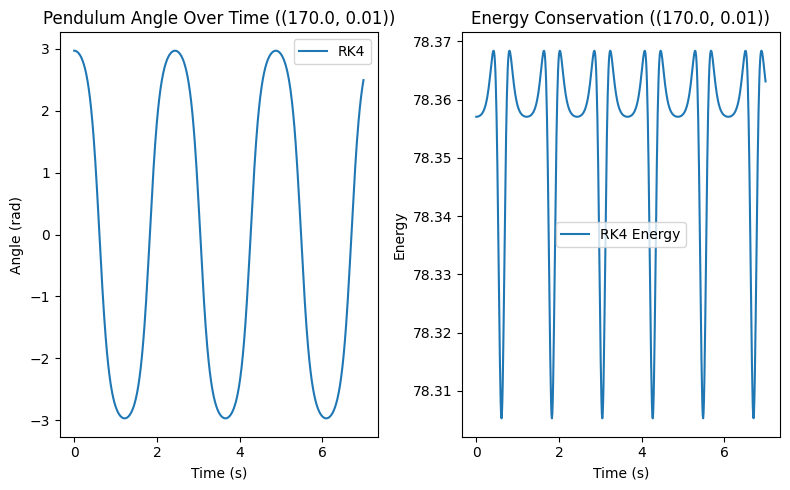

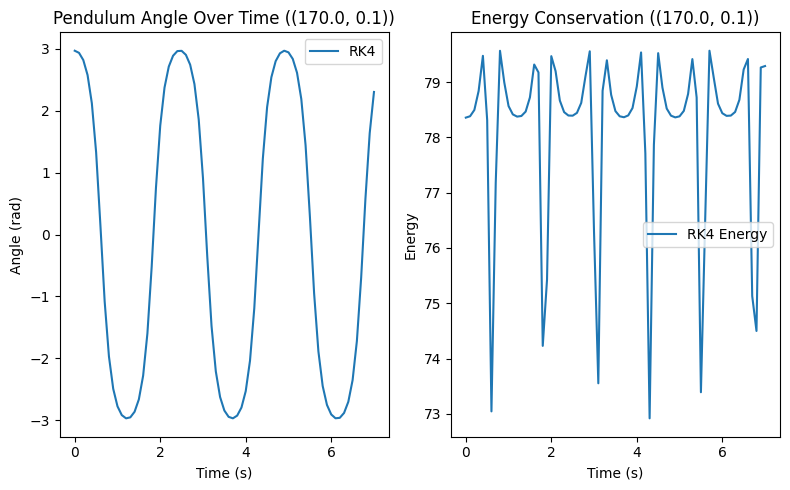

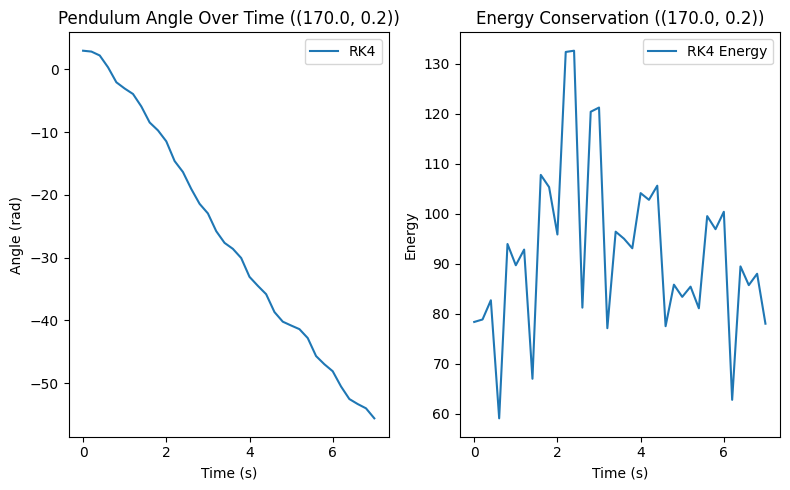

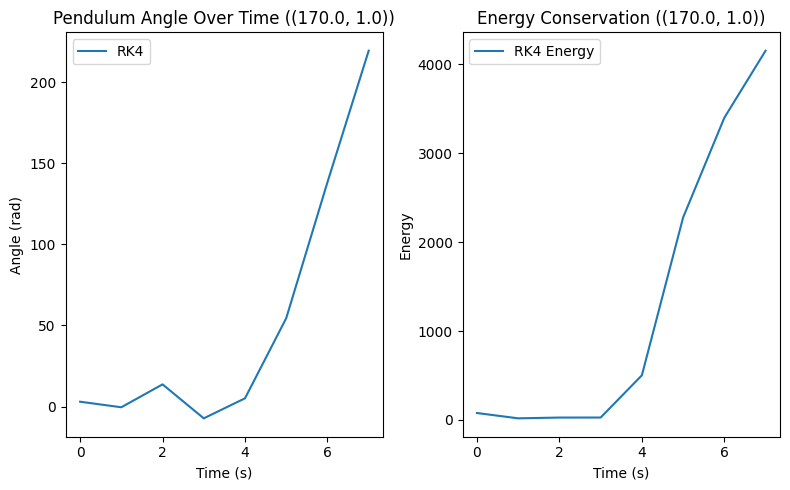

In [6]:
# Add your code here

tau_vec = np.array([0.01, 0.1, 0.2, 1])
theta0_vec = np.array([10, 45, 90, 170])

for i, theta0_deg in enumerate(theta0_vec):
    for j, tau in enumerate(tau_vec):

        # Define parameters
        T = 7       # Total integration time
        numSteps = int(np.ceil(T / tau))
        time = np.arange(numSteps + 1) * tau

        # Initial conditions
        theta0 = np.radians(theta0_deg)
        x0 = np.array([theta0, 0.0])  # [theta, omega]

        x_vals = [x0]
        e_vals = [pendulum_energy(x0)]

        # Define RHS of the pendulum ODEs
        def rhs_pend(x):
            theta, omega = x
            dtheta_dt = omega
            domega_dt = -4 * np.pi**2 * np.sin(theta)
            return np.array([dtheta_dt, domega_dt])

        # Function to compute energy
        def pendulum_energy(x):
            theta, omega = x
            kinetic = 0.5 * omega**2
            potential = 4 * np.pi**2 * (1 - np.cos(theta))
            return kinetic + potential

        x = x0
        for _ in range(numSteps):
            theta, omega = x

            theta_n = theta.copy()
            theta = theta_n + tau * omega - 0.5 * tau**2 * 4 * np.pi**2 * np.sin(theta_n)
            omega = omega - 0.5 * tau * (4 * np.pi**2 * np.sin(theta_n) + 4 * np.pi**2 * np.sin(theta))

            x = np.array([theta, omega])
            x_vals.append(x)
            e_vals.append(pendulum_energy(x))


        x_vals = np.array(x_vals)
        e_vals = np.array(e_vals)

        # Plot theta over time
        plt.figure(figsize=(8, 5))
        plt.subplot(1, 2, 1)
        plt.plot(time, x_vals[:, 0], label="RK4")
        plt.xlabel("Time (s)")
        plt.ylabel("Angle (rad)")
        plt.title(f"Pendulum Angle Over Time ({float(theta0_deg), float(tau)})")
        plt.legend()

        # Plot energy over time
        plt.subplot(1, 2, 2)
        plt.plot(time, e_vals, label="RK4 Energy")
        plt.xlabel("Time (s)")
        plt.ylabel("Energy")
        plt.title(f"Energy Conservation ({float(theta0_deg), float(tau)})")
        plt.legend()
        plt.tight_layout()
        plt.show()


|      | 10 | 45 | 90 | 170 |
|------|----|----|----|-----|
| 0.01 |  A  |  A  |  A  |   A  |
| 0.1  |  A  |  A  |  A  |   A  |
| 0.2  |  A  |  I  |  I  |   I  |
| 1    |  I  |  I  |  I |   I  |

*Your notes:*

## <span style="color:red">Q4</span>
### We know that RK4 is more accurate than Velocity-Verlet in each single step, but that how much of an advantage does it give it for this simple pendulum problem?

*Your notes:*

# Part II: Solving the Kepler problem with RK4

These questions involve modifying the code from lecture 2, which solves the Kepler problem using the Verlet method, to instead use the fourth order Runge-Kutta method.

In this question we will work with kepler_verlet.ipynb. Follow the steps outlined in Canvas Quiz to modify the code to implement fourth-order Runge-Kutta, rather than Verlet, for the circular motion test case. 

[refer to Canvas Quiz Computational Physics Lab 3 for detail]

Once you have your code working, answer the following questions.


In [7]:
def kepler_analytic(vel,T):

    #-------------------------------------------------------------------------------
    # Calculate the analytic trajectory for the Kepler central force problem.
    # Assumes an initial position r = (1,0), v = (0,vel).
    #-------------------------------------------------------------------------------
    # INPUTS:
    # - vel: the initial speed.
    # - T: sets an upper limit for |theta| for the e > 1 case (plot up to the
    #        integration time).
    #-------------------------------------------------------------------------------

    # Calculate trajectory from analytic solution

    ecc = np.linalg.norm(vel)**2 - 1        # Eccentricity
    a = 1/(1 - ecc)                         # Semi-major axis

    if ecc < 1:

        theta = np.linspace(0, 2*np.pi, 50) # Equally spaced values from 0 to 2*pi
        b = a * np.sqrt(1 - ecc**2)
        xan = -a * ecc + a * np.cos(theta)
        yan =  b * np.sin(theta)

    else:

        b = a * np.sqrt(ecc**2 - 1)
        theta_max = np.asinh(np.linsalg.norm(vel) * T/b) # Limit for range of theta
        that = np.linspace( -theta_max, theta_max, 50)
        xan = - a * ecc + a * np.cosh(theta)
        yan =   b * np.sinh(theta)

    return xan, yan

In [8]:
def kepler_verlet(tau=0.0005, pos=np.array([1.0, 0.0]), vel=np.array([0.0, 1.0])):
    # Total integration time (non-dimensional)
    T = 4 * np.pi

    # Number of integration steps
    numSteps = int(np.ceil(T / tau))

    # Preallocate arrays for speed:
    time = tau * np.arange(numSteps + 1)
    x = np.zeros(numSteps + 1)
    y = np.zeros(numSteps + 1)
    energy = np.zeros(numSteps + 1)
    local_error = np.zeros(numSteps + 1)
    global_error = np.zeros(numSteps + 1)
    energy_error = np.zeros(numSteps + 1)

    # Set initial values:
    x[0], y[0] = pos
    speed = np.linalg.norm(vel)
    r = np.linalg.norm(pos)
    accel = -pos / r**3
    energy[0] = 0.5 * speed**2 - 1 / r

    # Exact solution for reference:
    x_exact = np.cos(time)
    y_exact = np.sin(time)

    # Verlet method integration
    for n in range(1, numSteps + 1):
        # Take one step of the Verlet Method to update position
        if n == 1:
            # Get started with a midpoint method step
            next_pos = pos + tau * vel + 0.5 * tau**2 * accel
        else:
            # Normal Verlet update:
            next_pos = 2 * pos - prev + tau**2 * accel

        # Take one step of the Verlet Method to update velocity
        if n == 1:
            r = np.linalg.norm(next_pos)
            accel_n2 = -next_pos / r**3
            vel = vel + tau / 2 * (accel + accel_n2)
        else:
            vel = (next_pos - prev) / (2 * tau)

        # Calculate speed, radial position, and acceleration after taking the step:
        speed = np.linalg.norm(vel)
        r = np.linalg.norm(next_pos)
        accel = -next_pos / r**3

        # Update energy after taking the step:
        energy[n] = 0.5 * speed**2 - 1 / r

        # Store position update:
        x[n] = next_pos[0]
        y[n] = next_pos[1]

        # Compute local error (difference between numerical and exact solution at each step)
        local_error[n] = np.sqrt((x[n] - x_exact[n])**2 + (y[n] - y_exact[n])**2)
        
        # Compute global error (cumulative sum of local errors)
        global_error[n] = global_error[n-1] + local_error[n]
        
        # Compute energy error (relative difference from initial energy)
        energy_error[n] = np.abs((energy[n] - energy[0]) / energy[0])

        # Update 'prev' and 'pos' to calculate 'next' in the following step:
        prev = pos
        pos = next_pos

    return x, y, time, energy

x, y, time, energy = kepler_verlet()

In [9]:
def rhs_kepler(x):
    rhs = np.zeros(4)

    rhs[0] = x[2]
    rhs[1] = x[3]

    rcubed = (x[0]**2 + x[1]**2)**1.5
    rhs[2] = -x[0] / rcubed
    rhs[3] = -x[1] / rcubed

    return rhs

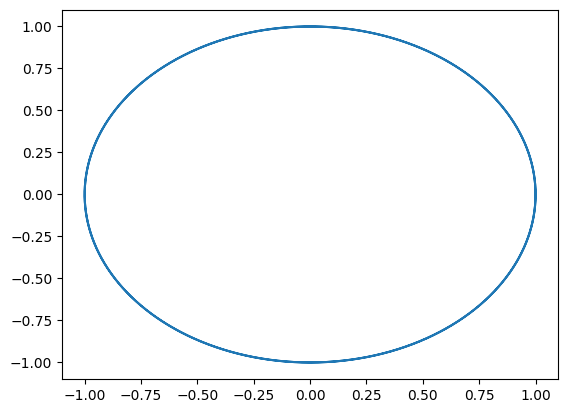

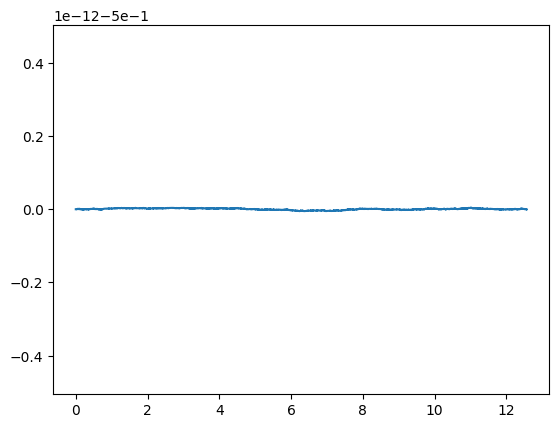

In [10]:
def rhs_kepler(x):
    rhs = np.zeros(4)

    rhs[0] = x[2]
    rhs[1] = x[3]

    rcubed = (x[0]**2 + x[1]**2)**1.5
    rhs[2] = -x[0] / rcubed
    rhs[3] = -x[1] / rcubed

    return rhs


def kepler_RK4(tau=0.0005, pos=np.array([1.0, 0.0]), vel=np.array([0.0, 1.0])):
    # Total integration time (non-dimensional)
    T = 4 * np.pi

    # Number of integration steps
    numSteps = int(np.ceil(T / tau))

    # Preallocate arrays for speed:
    time = tau * np.arange(numSteps + 1)
    x = np.zeros(numSteps + 1)
    y = np.zeros(numSteps + 1)
    energy = np.zeros(numSteps + 1)
    local_error = np.zeros(numSteps + 1)
    global_error = np.zeros(numSteps + 1)
    energy_error = np.zeros(numSteps + 1)

    # Set initial values:
    x[0], y[0] = pos
    speed = np.linalg.norm(vel)
    r = np.linalg.norm(pos)
    accel = -pos / r**3
    energy[0] = 0.5 * speed**2 - 1 / r

    # Exact solution for reference:
    x_exact = np.cos(time)
    y_exact = np.sin(time)

    # Verlet method integration
    for n in range(1, numSteps + 1):
        # One step of RK4 method:
        x_vec = [pos[0], pos[1], vel[0], vel[1]]
        
        f1 = rhs_kepler(x_vec)
        f2 = rhs_kepler(x_vec + 0.5*tau*f1)
        f3 = rhs_kepler(x_vec + 0.5*tau*f2)
        f4 = rhs_kepler(x_vec + tau*f3)

        # Update x vector
        xn, yn, vxn, vyn = x_vec + tau*(f1 + 2*f2 + 2*f3 + f4)/6
        next_pos = np.array([xn, yn])
        vel = np.array([vxn, vyn])

        # Calculate speed, radial position, and acceleration after taking the step:
        speed = np.linalg.norm(vel)
        r = np.linalg.norm(next_pos)

        # Update energy after taking the step:
        energy[n] = 0.5 * speed**2 - 1 / r

        # Store position update:
        x[n] = next_pos[0]
        y[n] = next_pos[1]

        # Compute local error (difference between numerical and exact solution at each step)
        local_error[n] = np.sqrt((x[n] - x_exact[n])**2 + (y[n] - y_exact[n])**2)
        
        # Compute global error (cumulative sum of local errors)
        global_error[n] = global_error[n-1] + local_error[n]
        
        # Compute energy error (relative difference from initial energy)
        energy_error[n] = np.abs((energy[n] - energy[0]) / energy[0])

        # update position
        pos = next_pos

    return x, y, time, energy

x, y, time, energy = kepler_RK4()

plt.plot(x, y)
plt.show()
plt.plot(time, energy)
plt.show()

## <span style="color:red">Q5</span>

### How well does RK4 perform on the circular motion test case (initial vector ${\bf x}=[1,0,0,1]$), with the default time step ($\tau=0.05$)?

In [ ]:
import os

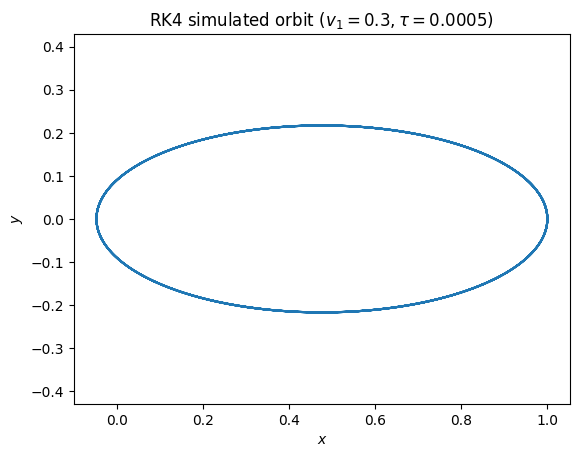

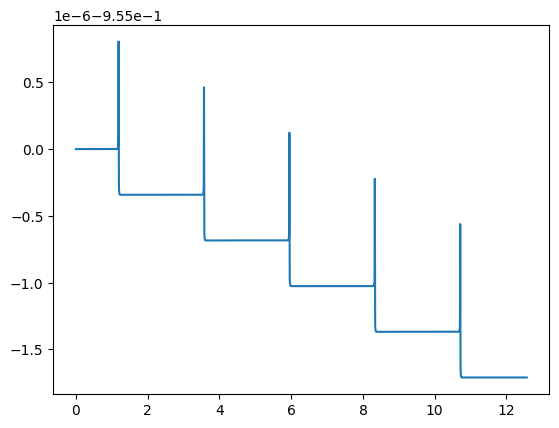

In [24]:
# Add your code here

plt.close()
pos = np.array([1, 0])
vel = np.array([0, 0.3])

x, y, time, energy = kepler_RK4(tau=0.0005, pos=pos, vel=vel)

plt.plot(x, y)
plt.axis('equal')
plt.title(fr"RK4 simulated orbit $(v_1 = 0.3, \tau=0.0005)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.savefig("simulated_orbit.png")
plt.show()

plt.plot(time, energy)
plt.show()


*Your notes:*

## <span style="color:red">Q6</span>

### Apply the RK4 scheme to simulate a highly eccentric case (v₁ = 0.3).
 
Step through orders of magnitude (e.g., τ = 0.05, 0.005, ...) to identify an estimate of the largest time step, τ, which yields a reasonably accurate orbit.

In [12]:
# Add your code here

*Your notes:*

## <span style="color:red">Q7</span>

### Apply the RK4 scheme to simulate a highly eccentric initial condition, $\mathbf{x}=[1,0,0,0.3]$, from Question 6.


In [13]:
# Add your code here

*Your notes:*

## <span style="color:red">Q8</span>

### Summarize the comparison of RK4 to the Verlet method on the Kepler problem.

*Your notes:*